# Aq2 / Kq2 — Forward Heat-Flow Model
---
**Pipeline**

```
Input 5 km FUSED ensemble grid (notebook 7 pooled quantiles)   [config.FORWARD_USE_FUSION]
  |   (falls back to the QRF-only grid if FORWARD_USE_FUSION = False)
  |
  +-- STEP 1  Oversampling   5 km -> BedMachine resolution
  |           Bicubic interpolation + per-cell conservative correction
  |           target spacing: 500 m (Antarctica) / 150 m (Greenland)
  |
  +-- STEP 2  Volcanic / hydrothermal kernel modification
  |           Multiplicative zero-sum Mexican-hat kernels (log-additive)
  |
  +-- STEP 3  Topographic correction (Colgan-style)
              2-D k_rock / k_ice, where k_ice = k_ice(T_b) is temperature-dependent
              (Cuffey & Paterson 2010).  Basal temperature, upper-crust
              conductivity and hydrology are READ FROM per-region input files
              (Phase-1 placeholders generated by scripts/make_forward_placeholders.py).
```

**Conservation invariant:** every step preserves total integrated heat.
Global mean is verified at each stage and stored in NetCDF metadata.

**Development subset:** when `config.DEV_SUBSET = True` the pipeline is cropped to
a small full-resolution bounding box (config.DEV_SUBSET_BBOX; default West Marie
Byrd Land) so the whole chain can be exercised quickly. Cache files are tagged
with `config.DEV_SUBSET_TAG` so subset and full-grid caches never collide. Set
`DEV_SUBSET = False` in config to process the entire grid.


## 1 — Imports and setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

import cmcrameri.cm as cmc  # noqa: F401  (registers "cmc.*" colormaps)
import sys; sys.path.insert(0, str(Path(".").resolve()))
from config import *
from lib.forward import (
    load_empirical_grid, load_volcano_catalogue, load_hydrothermal_catalogue,
    oversample_to_bedmachine, apply_volcanic_kernels,
    topographic_correction, save_forward_product,
    k_ice_from_temperature, crop_to_bbox,
)
from lib.uncertainty import compute_uncertainty_summary


def resolve_cmap(cmap):
    """Return a Colormap object from a name/spec so pcolormesh never depends on
    cmcrameri's string registration being active. Accepts a Colormap (returned
    as-is), a "cmc.<name>" spec (resolved via cmcrameri.cm), or any Matplotlib
    colormap name."""
    import matplotlib as mpl
    if isinstance(cmap, mpl.colors.Colormap):
        return cmap
    if isinstance(cmap, str) and cmap.startswith("cmc."):
        return getattr(cmc, cmap.split(".", 1)[1])
    return mpl.colormaps[cmap]


# Pre-resolve the config colormap *strings* into objects once, up front, and
# rebind the lower-case config names so EVERY reference in this notebook is a
# Colormap object (robust: no dependence on cmcrameri string registration).
HF_CMAP  = resolve_cmap(hf_cmap)
UNC_CMAP = resolve_cmap(unc_cmap)
hf_cmap  = HF_CMAP
unc_cmap = UNC_CMAP

print("Imports OK")


✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
Imports OK


## 2 — Configuration

In [2]:
with open("forward_params.yaml") as f:
    FP = yaml.safe_load(f)

REGION    = FP["region"]
CHUNKS    = FP["oversampling"]["dask_chunks"]
FINAL_DIR = Path(FP["output"]["final_dir"])
TEMP_DIR  = Path(FP["output"]["temp_dir"])
TEMP_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Region  : {REGION}")
print(f"Temp    : {TEMP_DIR}")
print(f"Output  : {FINAL_DIR}")

Region  : antarctica
Temp    : temp
Output  : output


In [3]:
# ── Cache tag: keep dev-subset and full-grid caches separate ─────────────────
CACHE_TAG = f"_{DEV_SUBSET_TAG}" if DEV_SUBSET else ""


def _tag(name):
    """Insert CACHE_TAG before the file extension of a cache filename."""
    p = Path(name)
    return f"{p.stem}{CACHE_TAG}{p.suffix}"


# ── Input grid: fused ensemble (best practice) or QRF-only fallback ──────────
def _fusion_nc(region):
    key = "ant" if region == "antarctica" else "grl"
    return ENSEMBLE_DIR / f"{key}_ensemble_v{MODEL_VERSION}.nc"


if REGION == "antarctica":
    BM_FILE    = bedmachine_antarctica_file
    INPUT_NC   = (_fusion_nc("antarctica") if FORWARD_USE_FUSION
                  else targets_dir / f"Aq1_5_QRF_v{MODEL_VERSION}.nc")
    REGION_CRS = ant_crs
    OUTPUT_NC  = FINAL_DIR / _tag(FP["output"]["ant_forward_nc"])
    CACHE_S1   = TEMP_DIR  / _tag(FP["output"]["cache_step1_ant"])
    CACHE_S2   = TEMP_DIR  / _tag(FP["output"]["cache_step2_ant"])
    BASAL_T_NC = FORWARD_BASAL_TEMP_NC["antarctica"]
    K_CRUST_NC = FORWARD_K_CRUST_NC["antarctica"]
    HYDRO_NC   = FORWARD_HYDROLOGY_NC["antarctica"]
else:
    BM_FILE    = bedmachine_greenland_file
    INPUT_NC   = (_fusion_nc("greenland") if FORWARD_USE_FUSION
                  else targets_dir / f"Kq1_5_QRF_v{MODEL_VERSION}.nc")
    REGION_CRS = grl_crs
    OUTPUT_NC  = FINAL_DIR / _tag(FP["output"]["grl_forward_nc"])
    CACHE_S1   = TEMP_DIR  / _tag(FP["output"]["cache_step1_grl"])
    CACHE_S2   = TEMP_DIR  / _tag(FP["output"]["cache_step2_grl"])
    BASAL_T_NC = FORWARD_BASAL_TEMP_NC["greenland"]
    K_CRUST_NC = FORWARD_K_CRUST_NC["greenland"]
    HYDRO_NC   = FORWARD_HYDROLOGY_NC["greenland"]

print(f"Input grid : {INPUT_NC.name}  "
      f"({'FUSED ensemble' if FORWARD_USE_FUSION else 'QRF-only fallback'})")
print(f"Basal T    : {BASAL_T_NC.name}")
print(f"k_crust    : {K_CRUST_NC.name}")
if DEV_SUBSET:
    print(f"DEV_SUBSET : ON  (tag='{DEV_SUBSET_TAG}', region='{DEV_SUBSET_REGION}')")
    if REGION != DEV_SUBSET_REGION:
        print(f"  ! note: DEV_SUBSET_BBOX is defined for '{DEV_SUBSET_REGION}', "
              f"but REGION='{REGION}' — crop will be skipped for this region.")

bedmachine   = xr.open_dataset(BM_FILE, chunks=CHUNKS)
FINE_SPACING = float(bedmachine.attrs.get("spacing", 500.0))
print(f"BedMachine : spacing={FINE_SPACING:.0f} m")

# ── Development crop (bounding box, region CRS metres) ───────────────────────
# Applied to BedMachine here and to the 5 km input grid right after loading,
# so every downstream step operates on the same small patch.
if DEV_SUBSET and REGION == DEV_SUBSET_REGION:
    bb = DEV_SUBSET_BBOX
    bedmachine = crop_to_bbox(bedmachine, bb["x_min"], bb["x_max"],
                              bb["y_min"], bb["y_max"])
    print(f"  cropped BedMachine to bbox -> "
          f"{bedmachine.dims.get('y','?')} x {bedmachine.dims.get('x','?')} cells")
print(bedmachine)


Input grid : ant_ensemble_v0_5.nc  (FUSED ensemble)
Basal T    : ant_basal_temperature.nc
k_crust    : ant_k_upper_crust.nc
DEV_SUBSET : ON  (tag='devMBL', region='antarctica')
BedMachine : spacing=500 m
  cropped BedMachine to bbox -> 1181 x 1181 cells
<xarray.Dataset> Size: 35MB
Dimensions:    (y: 1181, x: 1181)
Coordinates:
  * y          (y) int32 5kB -925000 -925500 -926000 ... -1514500 -1515000
  * x          (x) int32 5kB -1240000 -1239500 -1239000 ... -650500 -650000
Data variables:
    mapping    |S1 1B ...
    mask       (y, x) int8 1MB dask.array<chunksize=(1181, 1181), meta=np.ndarray>
    firn       (y, x) float32 6MB dask.array<chunksize=(1181, 1181), meta=np.ndarray>
    surface    (y, x) float32 6MB dask.array<chunksize=(1181, 1181), meta=np.ndarray>
    thickness  (y, x) float32 6MB dask.array<chunksize=(1181, 1181), meta=np.ndarray>
    bed        (y, x) float32 6MB dask.array<chunksize=(1181, 1181), meta=np.ndarray>
    errbed     (y, x) float32 6MB dask.array<chunks

In [4]:
ds_5km = load_empirical_grid(INPUT_NC, region=REGION, chunks=None)

# Match the development crop applied to BedMachine so the grids stay aligned.
if DEV_SUBSET and REGION == DEV_SUBSET_REGION:
    bb = DEV_SUBSET_BBOX
    ds_5km = crop_to_bbox(ds_5km, bb["x_min"], bb["x_max"],
                          bb["y_min"], bb["y_max"])
    print(f"cropped 5 km input to dev bbox -> "
          f"{ds_5km.dims.get('y','?')} x {ds_5km.dims.get('x','?')} cells")

print(ds_5km)



────────────────────────────────────────────────────────────
  Loading empirical 5 km grid — antarctica
────────────────────────────────────────────────────────────
  Grid: 1334 x 1334 cells
  Global mean q_mean: 52.826 mW/m2
cropped 5 km input to dev bbox -> 118 x 118 cells
<xarray.Dataset> Size: 1MB
Dimensions:             (y: 118, x: 118)
Coordinates:
  * y                   (y) float64 944B -1.512e+06 -1.507e+06 ... -9.27e+05
  * x                   (x) float64 944B -1.238e+06 -1.233e+06 ... -6.53e+05
Data variables: (12/19)
    q_q05               (y, x) float32 56kB dask.array<chunksize=(118, 118), meta=np.ndarray>
    q_q25               (y, x) float32 56kB dask.array<chunksize=(118, 118), meta=np.ndarray>
    q_q50               (y, x) float32 56kB dask.array<chunksize=(118, 118), meta=np.ndarray>
    q_q75               (y, x) float32 56kB dask.array<chunksize=(118, 118), meta=np.ndarray>
    q_q95               (y, x) float32 56kB dask.array<chunksize=(118, 118), meta=np.nda

## 3 — Step 1: Oversampling

Bicubic interpolation from 5 km to BedMachine resolution, followed by
per-cell conservative correction.  Each coarse 5 km cell's mean is preserved
exactly on the fine grid.  Global mean is also verified.

No new spatial information is added — this step removes block artefacts only.

In [5]:
def _cache_valid(cache_path, source_path):
    p, s = Path(cache_path), Path(source_path)
    return p.exists() and p.stat().st_mtime > s.stat().st_mtime

if _cache_valid(CACHE_S1, INPUT_NC):
    print(f"Loading Step 1 from cache: {CACHE_S1}")
    ds_step1 = xr.open_dataset(CACHE_S1, chunks=CHUNKS)
else:
    ds_step1 = oversample_to_bedmachine(
        ds_5km         = ds_5km,
        bedmachine     = bedmachine,
        fine_spacing   = FINE_SPACING,
        coarse_spacing = FP["oversampling"]["coarse_spacing_m"],
        mean_tol       = FP["oversampling"]["global_mean_tol"],
    )
    print("Computing oversampled grid ...")
    ds_step1 = ds_step1.compute()
    ds_step1.to_netcdf(CACHE_S1)
    print(f"Cached to {CACHE_S1}")


────────────────────────────────────────────────────────────
  STEP 1 — Oversampling 5 km to BedMachine resolution
────────────────────────────────────────────────────────────
  5000 m to 500 m  (factor 10.0x)
  Variables: ['q_q05', 'q_q25', 'q_q50', 'q_q75', 'q_q95', 'q_std', 'q_mean']
  ✗  WARNING  [q_q50]  before=58.5893  after=58.6972  delta=107.978 µW/m²  (tol=1.0 µW/m²)
  ✗  WARNING  [q_mean]  before=58.5893  after=58.6972  delta=107.978 µW/m²  (tol=1.0 µW/m²)
  Output: 1181 x 1181 = 1.4M pixels
Computing oversampled grid ...
Cached to temp/ant_step1_oversample_devMBL.nc


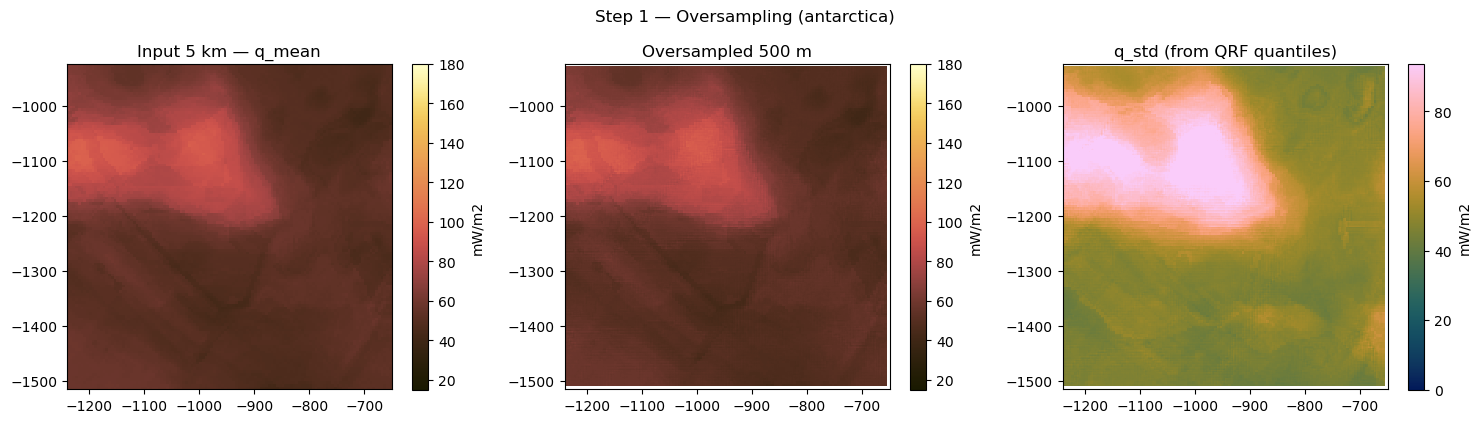

  5 km input       mean=58.589  std=13.071  min=39.811  max=99.233  mW/m2
  oversampled      mean=58.697  std=13.153  min=39.326  max=100.208  mW/m2


In [6]:
import cmcrameri.cm as cmc
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].pcolormesh(ds_5km.x/1e3, ds_5km.y/1e3, ds_5km["q_mean"]*1e3,
                          cmap=HF_CMAP, vmin=hf_v_min, vmax=hf_v_max, rasterized=True)
axes[0].set_title("Input 5 km — q_mean"); axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0], label="mW/m2")

im1 = axes[1].pcolormesh(ds_step1.x/1e3, ds_step1.y/1e3, ds_step1["q_mean"]*1e3,
                          cmap=HF_CMAP, vmin=hf_v_min, vmax=hf_v_max, rasterized=True)
axes[1].set_title(f"Oversampled {FINE_SPACING:.0f} m"); axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1], label="mW/m2")

_std_p95 = float(ds_step1["q_std"].quantile(0.95).values)*1e3
im2 = axes[2].pcolormesh(ds_step1.x/1e3, ds_step1.y/1e3, ds_step1["q_std"]*1e3,
                          cmap=UNC_CMAP, vmin=0, vmax=_std_p95, rasterized=True)
axes[2].set_title("q_std (from QRF quantiles)"); axes[2].set_aspect("equal")
plt.colorbar(im2, ax=axes[2], label="mW/m2")

plt.suptitle(f"Step 1 — Oversampling ({REGION})", y=1.01)
plt.tight_layout()
plt.savefig(fig_root / "forward_step1_oversample.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

for lbl, da in [("5 km input", ds_5km["q_mean"]), ("oversampled", ds_step1["q_mean"])]:
    v = da.values.ravel(); v = v[np.isfinite(v)]*1e3
    print(f"  {lbl:15s}  mean={v.mean():.3f}  std={v.std():.3f}  "
          f"min={v.min():.3f}  max={v.max():.3f}  mW/m2")

## 4 — Step 2: Volcanic / Hydrothermal Kernels

A multiplicative Mexican-hat (difference-of-Gaussians) kernel is placed at
each source via FFT convolution.  Kernels combine log-additively.

The total multiplier field is normalised over ice cells so its mean equals 1.0
— no net heat is created or destroyed.

Kernel classes: `active_volcano`, `pleistocene_volcano`.
(`hydrothermal` for Greenland — placeholder CSV path set in yaml.)

**Uncertainty:** variance inflated in quadrature using kernel amplitude
uncertainty (sigma_factor) and feature-existence probability (p_exists).
Both are currently global placeholders; per-feature override via catalogue
columns is supported (Phase 2).

In [7]:
vp = FP["volcanic"]
catalogue = load_volcano_catalogue(
    volc_list_path   = vp["volc_list_path"],
    holocene_path    = vp["holocene_path"],
    pleistocene_path = vp["pleistocene_path"],
)
# Greenland: uncomment when vent catalogue is ready
# vent_cat  = load_hydrothermal_catalogue(FP["hydrothermal"]["catalogue_csv"])
# catalogue = pd.concat([catalogue, vent_cat], ignore_index=True)
print(catalogue[["lat","lon","kernel_class","group"]].head(10))

  Volcano catalogue: 2877 features
kernel_class
pleistocene_volcano    1447
active_volcano         1430
         lat         lon         kernel_class    group
0 -71.616667  170.550000  pleistocene_volcano  McMurdo
1 -72.433333  170.200000  pleistocene_volcano  McMurdo
2 -72.950000  169.366667  pleistocene_volcano  McMurdo
3 -71.933333  171.183333  pleistocene_volcano  McMurdo
4 -73.550000  169.616667  pleistocene_volcano  McMurdo
5 -72.966667  167.300000  pleistocene_volcano  McMurdo
6 -72.666667  165.500000  pleistocene_volcano  McMurdo
7 -73.166667  164.583333  pleistocene_volcano  McMurdo
8 -74.350000  164.700000  pleistocene_volcano  McMurdo
9 -73.650000  163.666667  pleistocene_volcano  McMurdo


In [8]:
kernel_params = {
    **{k: v for k, v in vp["kernel_classes"].items()},
    "default_p_exists":     vp["default_p_exists"],
    "default_sigma_factor": vp["default_sigma_factor"],
}

if _cache_valid(CACHE_S2, CACHE_S1):
    print(f"Loading Step 2 from cache: {CACHE_S2}")
    ds_step2 = xr.open_dataset(CACHE_S2, chunks=CHUNKS)
else:
    ds_step2 = apply_volcanic_kernels(
        ds=ds_step1, catalogue=catalogue, kernel_params=kernel_params,
        bedmachine=bedmachine, region_crs=REGION_CRS, fine_spacing=FINE_SPACING,
        mean_tol=FP["oversampling"]["global_mean_tol"],
    )
    ds_step2 = ds_step2.compute()
    ds_step2.to_netcdf(CACHE_S2)
    print(f"Cached to {CACHE_S2}")


────────────────────────────────────────────────────────────
  STEP 2 — Volcanic / hydrothermal kernel modification
────────────────────────────────────────────────────────────
  Features in grid extent: 19 / 2877
  Kernel [active_volcano]: 401x401 px  sum=-602056.208556
  Kernel [pleistocene_volcano]: 401x401 px  sum=-320454.499566
  Multiplier (post-norm, ice):  min=0.0000  max=2.8582  mean=1.000000
  ✗  WARNING  [step2 q_mean]  before=58.6972  after=92.6909  delta=33993.699 µW/m²  (tol=1.0 µW/m²)
Cached to temp/ant_step2_volcanic_devMBL.nc


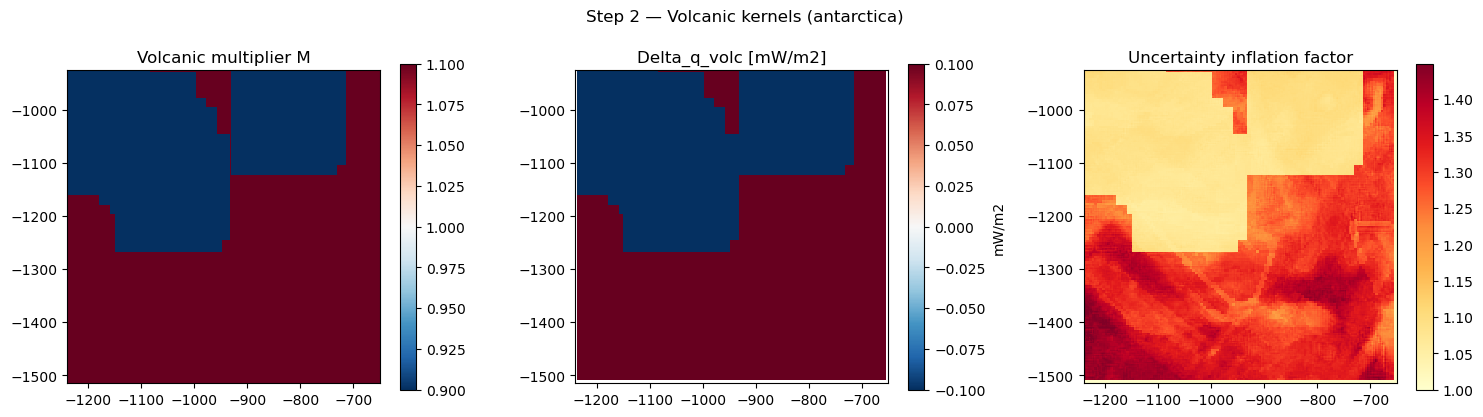

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
_dv_max = float(np.abs(ds_step2["delta_volc"].values).max())*1e3

im0 = axes[0].pcolormesh(ds_step2.x/1e3, ds_step2.y/1e3, ds_step2["volc_multiplier"],
                          cmap="RdBu_r", vmin=0.9, vmax=1.1, rasterized=True)
axes[0].set_title("Volcanic multiplier M"); axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(ds_step2.x/1e3, ds_step2.y/1e3, ds_step2["delta_volc"]*1e3,
                          cmap="RdBu_r", vmin=-_dv_max, vmax=_dv_max, rasterized=True)
axes[1].set_title("Delta_q_volc [mW/m2]"); axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1], label="mW/m2")

_inf_max = float(np.nanpercentile(ds_step2["volc_inflate_factor"].values, 99.9))
im2 = axes[2].pcolormesh(ds_step2.x/1e3, ds_step2.y/1e3, ds_step2["volc_inflate_factor"],
                          cmap="YlOrRd", vmin=1, vmax=_inf_max, rasterized=True)
axes[2].set_title("Uncertainty inflation factor"); axes[2].set_aspect("equal")
plt.colorbar(im2, ax=axes[2])

plt.suptitle(f"Step 2 — Volcanic kernels ({REGION})", y=1.01)
plt.tight_layout()
plt.savefig(fig_root / "forward_step2_volcanic.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 5 — Step 3: Topographic Correction

Colgan-style correction using BedMachine bed/surface topography.

$$\Delta G_{\text{bed}}  = q \cdot \frac{k_{\text{rock}}}{k_{\text{ref}}} \cdot \frac{z_{\text{bed}} - \bar{z}_{\text{bed}}}{r}$$

$$\Delta G_{\text{ice}}  = q \cdot \frac{k_{\text{ice}}}{k_{\text{ref}}} \cdot \frac{z_{\text{surf}} - z_{\text{bed}}}{r}$$

**Phase 1:** spatially constant $k_{\text{rock}}=1.8$ and $k_{\text{ice}}=2.1$ W m$^{-1}$ K$^{-1}$.

**BedMachine coverage:** correction applied only where direct observations exist.
Ocean cells use $k_{\text{ocean}}=6.0$ W m$^{-1}$ K$^{-1}$ (placeholder).
Submarine correction is **not implemented** — noted in NetCDF attributes.

In [10]:
tp = FP["topo_correction"]

# ── Read gridded input fields (Phase-1 placeholders on the 5 km fusion grid) ─
# Basal temperature drives the temperature-dependent ice conductivity; upper-
# crust conductivity is read directly. Both are generated by
# scripts/make_forward_placeholders.py. They live on the 5 km grid, so we
# interpolate onto the oversampled step-2 grid before use.
def _read_field(path, var, like):
    da = xr.open_dataset(path)[var]
    if DEV_SUBSET and REGION == DEV_SUBSET_REGION:
        bb = DEV_SUBSET_BBOX
        da = crop_to_bbox(da.to_dataset(name=var), bb["x_min"], bb["x_max"],
                          bb["y_min"], bb["y_max"])[var]
    # nearest to the oversampled target grid (constant placeholders -> exact;
    # for real fields prefer method="linear")
    return da.interp(x=like["x"], y=like["y"], method="nearest")

t_basal = _read_field(BASAL_T_NC, "t_basal", ds_step2)          # degC
k_rock  = _read_field(K_CRUST_NC, "k_upper_crust", ds_step2)    # W/m/K
k_rock  = k_rock.astype(np.float32)
k_rock.attrs = {"units": "W m-1 K-1",
                "long_name": "Upper-crust conductivity (read from input file)",
                "source_file": K_CRUST_NC.name}

# Temperature-dependent ice conductivity k_ice(T_b), Cuffey & Paterson (2010).
k_ice = k_ice_from_temperature(
    t_basal, t_units=KICE_TEMPERATURE_UNITS,
    k_min=KICE_CLIP_MIN, k_max=KICE_CLIP_MAX,
).astype(np.float32)

k_rock_std = k_ice_std = None   # Phase 2: supply spatially varying std arrays

print(f"k_rock : read from {K_CRUST_NC.name}  "
      f"(mean {float(k_rock.mean()):.3f} W/m/K)")
print(f"t_basal: read from {BASAL_T_NC.name}  "
      f"(mean {float(t_basal.mean()):.3f} {KICE_TEMPERATURE_UNITS})")
print(f"k_ice  : k_ice(T_b) Cuffey & Paterson (2010)  "
      f"(mean {float(k_ice.mean()):.3f} W/m/K, "
      f"clipped to [{KICE_CLIP_MIN}, {KICE_CLIP_MAX}])")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/toby/proj/aq2/output/forward_inputs/ant_basal_temperature.nc'

In [11]:
ds_step3 = topographic_correction(
    ds           = ds_step2,
    bedmachine   = bedmachine,
    k_rock       = k_rock,
    k_ice        = k_ice,
    k_rock_std   = k_rock_std,
    k_ice_std    = k_ice_std,
    r_m          = tp["r_m"],
    k_ref        = tp["k_ref"],
    k_ocean      = tp["k_ocean"],
    clip_max     = tp["clip_max_Wm2"],
    apply_only_where_covered = tp["apply_only_where_bedmachine_direct"],
    fine_spacing = FINE_SPACING,
)
ds_step3 = ds_step3.compute()
print("Topographic correction complete")

NameError: name 'k_rock' is not defined

NameError: name 'ds_step3' is not defined

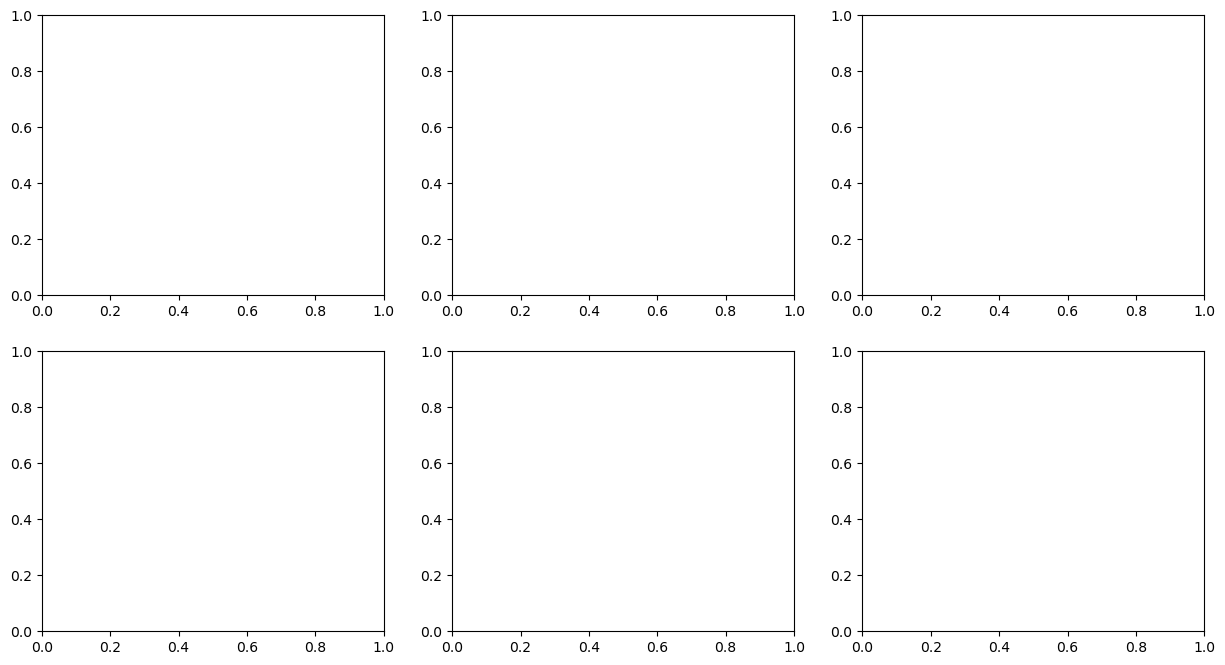

In [12]:
import cmcrameri.cm as cmc
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
_panels = [
    (axes[0,0], ds_step3["delta_G_bed"]*1e3,   "DeltaG_bed [mW/m2]",  "diverging"),
    (axes[0,1], ds_step3["delta_G_ice"]*1e3,   "DeltaG_ice [mW/m2]",  "diverging"),
    (axes[0,2], ds_step3["delta_topo"]*1e3,    "DeltaG_total [mW/m2]","diverging"),
    (axes[1,0], ds_step3["q_mean"]*1e3,        "q_mean post-topo",    hf_cmap),
    (axes[1,1], ds_step3["delta_topo_std"]*1e3,"DeltaG uncertainty",   UNC_CMAP),
    (axes[1,2], ds_step3["q_std"]*1e3,         "q_std (cumulative)",   UNC_CMAP),
]
for ax, da, title, cmap in _panels:
    vals = da.values
    vmax = float(np.nanpercentile(np.abs(vals[np.isfinite(vals)]), 99))
    diverging = (cmap == "diverging")
    vmin = -vmax if diverging else 0
    im = ax.pcolormesh(ds_step3.x/1e3, ds_step3.y/1e3, vals,
                       cmap=("RdBu_r" if diverging else cmap),
                       vmin=vmin, vmax=vmax, rasterized=True)
    ax.set_title(title, fontsize=9); ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, shrink=0.8, label="mW/m2")

plt.suptitle(f"Step 3 — Topographic correction ({REGION})", y=1.01)
plt.tight_layout()
plt.savefig(fig_root / "forward_step3_topo.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

## 6 — Uncertainty Summary

In [ ]:
ds_final = compute_uncertainty_summary(ds_step3)
unc_vars = [v for v in ds_final.data_vars if any(s in v for s in ("std","iqr","cv","ci90"))]
print("Uncertainty fields:", unc_vars)

In [ ]:
import cmcrameri.cm as cmc
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
_unc_p = [
    (axes[0,0], ds_final["q_mean"]*1e3,       "q_mean [mW/m2]",       HF_CMAP, (hf_v_min, hf_v_max)),
    (axes[0,1], ds_final["q_std"]*1e3,        "q_std [mW/m2]",        unc_cmap, None),
    (axes[0,2], ds_final["q_cv"]*100,         "CV = sigma/mu [%]",    "plasma", (0, 50)),
    (axes[1,0], ds_final["q_iqr"]*1e3,        "IQR (q25-q75) [mW/m2]",unc_cmap, None),
    (axes[1,1], ds_final["q_ci90_lower"]*1e3, "q_05 [mW/m2]",         HF_CMAP, (hf_v_min, hf_v_max)),
    (axes[1,2], ds_final["q_ci90_upper"]*1e3, "q_95 [mW/m2]",         HF_CMAP, (hf_v_min, hf_v_max)),
]
for ax, da, title, cmap, vlims in _unc_p:
    vals = da.values
    if vlims is None:
        vmax = float(np.nanpercentile(vals[np.isfinite(vals)], 98))
        vlims = (0, vmax)
    im = ax.pcolormesh(ds_final.x/1e3, ds_final.y/1e3, vals,
                       cmap=cmap, vmin=vlims[0], vmax=vlims[1], rasterized=True)
    ax.set_title(title, fontsize=9); ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle(f"Uncertainty summary ({REGION})", y=1.01)
plt.tight_layout()
plt.savefig(fig_root / "forward_uncertainty_summary.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

In [ ]:
mask_ice = (ds_final["mask"].values > 0).ravel()
rows = {}
for var in ["q_mean","q_std","q_iqr","delta_volc","delta_topo","delta_topo_std"]:
    if var not in ds_final: continue
    v = ds_final[var].values.ravel()
    v = v[mask_ice & np.isfinite(v)] * 1e3
    rows[var] = dict(mean=v.mean(), median=float(np.median(v)), std=v.std(),
                     p05=float(np.percentile(v,5)), p95=float(np.percentile(v,95)))
budget = pd.DataFrame(rows).T
budget.columns = ["mean","median","std","p05","p95"]
print("\nUncertainty budget (mW/m2, ice cells only):")
print(budget.round(3).to_string())

In [ ]:
high_unc_threshold = 0.50
high_unc = ds_final["q_cv"] > high_unc_threshold
n_high = int(high_unc.sum().values)
n_ice  = int(mask_ice.sum())
print(f"Cells with CV > {high_unc_threshold*100:.0f}%: "
      f"{n_high:,} / {n_ice:,} ({n_high/n_ice*100:.1f}%)")

## 7 — Save Outputs

In [ ]:
save_forward_product(
    ds=ds_final, out_path=OUTPUT_NC, region=REGION,
    model_version=MODEL_VERSION,
    compression_level=FP["output"]["compression_level"],
    author=NETCDF_AUTHOR,
)
print(f"\nFinal product: {OUTPUT_NC}")

In [ ]:
ds_check = xr.open_dataset(OUTPUT_NC)
print(ds_check)
print("\nGlobal attributes:")
for k, v in ds_check.attrs.items():
    print(f"  {k}: {v}")
ds_check.close()

## 8 — Paper Figures

Manuscript-quality figures generated from the saved NetCDF.
These cells are independent of Sections 3-7 and can be re-run
after loading the saved product without repeating the pipeline.

In [ ]:
ds_pub = xr.open_dataset(OUTPUT_NC)
print(f"Loaded {OUTPUT_NC}  ({Path(OUTPUT_NC).stat().st_size/1e6:.1f} MB)")

In [ ]:
import cmcrameri.cm as cmc
# Main heat-flow map
fig, ax = plt.subplots(figsize=(MAP_W_ANT*1.5, MAP_H_ANT*1.5))
im = ax.pcolormesh(ds_pub.x/1e3, ds_pub.y/1e3, ds_pub["q_mean"]*1e3,
                   cmap=HF_CMAP, vmin=hf_v_min, vmax=hf_v_max, rasterized=True)
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
cbar.set_label(f"Heat flow ({hf_unit})", fontsize=10)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")
ax.set_title(f"Geothermal heat flow — {REGION.capitalize()}")
plt.tight_layout()
plt.savefig(fig_root / f"paper_hf_mean_{REGION}.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import cmcrameri.cm as cmc
# Uncertainty triptych
fig, axes = plt.subplots(1, 3, figsize=(MAP_W_ANT*4, MAP_H_ANT*1.2))
for ax, var, title, cmap in [
    (axes[0], "q_std",  "sigma [mW/m2]",           unc_cmap),
    (axes[1], "q_cv",   "CV = sigma/mu [%]",        "plasma"),
    (axes[2], "q_iqr",  "IQR q25-q75 [mW/m2]",     unc_cmap),
]:
    mult = 100 if var == "q_cv" else 1e3
    vals = ds_pub[var].values * mult
    vmax = float(np.nanpercentile(vals[np.isfinite(vals)], 98))
    im = ax.pcolormesh(ds_pub.x/1e3, ds_pub.y/1e3, vals,
                       cmap=cmap, vmin=0, vmax=vmax, rasterized=True)
    ax.set_aspect("equal"); ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85, label="%" if var=="q_cv" else "mW/m2")
plt.suptitle(f"Uncertainty — {REGION.capitalize()}", y=1.01)
plt.tight_layout()
plt.savefig(fig_root / f"paper_uncertainty_{REGION}.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Correction fields
fig, axes = plt.subplots(1, 2, figsize=(MAP_W_ANT*2.5, MAP_H_ANT*1.2))
for ax, var, title in [
    (axes[0], "delta_volc",  "Volcanic correction [mW/m2]"),
    (axes[1], "delta_topo",  "Topographic correction [mW/m2]"),
]:
    vals = ds_pub[var].values * 1e3
    vmax = float(np.nanpercentile(np.abs(vals[np.isfinite(vals)]), 99))
    im = ax.pcolormesh(ds_pub.x/1e3, ds_pub.y/1e3, vals,
                       cmap="RdBu_r", vmin=-vmax, vmax=vmax, rasterized=True)
    ax.set_aspect("equal"); ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85, label="mW/m2")
plt.tight_layout()
plt.savefig(fig_root / f"paper_corrections_{REGION}.png", dpi=300, bbox_inches="tight")
plt.show()